# Sales Prediction dengan Machine Learning
**Fajri | Data Science Project**

---

## Tujuan Proyek
Membangun model Machine Learning untuk memprediksi jumlah penjualan harian berdasarkan fitur-fitur seperti promo, hari dalam minggu, dan bulan — menggunakan **dataset yang dibuat sendiri** secara sintetis.

## Alur Kerja (Pipeline)
1. Install & Import Library
2. Generate Dataset Sintetis
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Training & Perbandingan Model
6. Evaluasi & Visualisasi Hasil
7. Kesimpulan

>  **Cara pakai:** Jalankan setiap cell secara berurutan dengan menekan `Shift + Enter` atau klik tombol ▶ di sebelah kiri cell.

## 1. Install & Import Library

Semua library di bawah sudah tersedia di Google Colab. Tidak perlu install tambahan!

In [1]:
# ── Import semua yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LinearRegression
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics         import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing   import StandardScaler

# Konfigurasi tampilan
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.2f}'.format)

print('Semua library berhasil di-import!')
print(f'   NumPy     : {np.__version__}')
print(f'   Pandas    : {pd.__version__}')

Semua library berhasil di-import!
   NumPy     : 2.0.2
   Pandas    : 2.2.2


## 2. Generate Dataset Sintetis

Kita akan membuat dataset penjualan harian yang **realistis** secara sintetis menggunakan NumPy.

**Logika dataset:**
- Penjualan dasar (base) = 50 unit/hari
- Promo menambah 15–35 unit secara acak
- Akhir pekan menambah ~8 unit
- Ada pola musiman (sinus) + noise acak

In [4]:
# ── Reproduksi hasil yang sama setiap dijalankan
np.random.seed(42)

N = 1200  # ~3.5 tahun data harian

# ── Buat fitur dasar
dates       = pd.date_range(start='2022-01-01', periods=N, freq='D')
is_promo    = np.random.choice([0, 1], size=N, p=[0.75, 0.25])  # 25% hari ada promo
is_weekend  = (dates.dayofweek >= 5).astype(int)
month       = dates.month
day_of_week = dates.dayofweek
quarter     = dates.quarter

# ── Simulasi penjualan
base_sales   = 50
seasonal     = 10 * np.sin(2 * np.pi * dates.dayofyear / 365)   # pola tahunan
monthly_bump = np.where(dates.day >= 25, 12, 0)                  # lonjakan akhir bulan
promo_lift   = is_promo * np.random.uniform(15, 35, N)           # efek promo
weekend_lift = is_weekend * 8
noise        = np.random.normal(0, 5, N)

sales = (base_sales + seasonal + monthly_bump + promo_lift + weekend_lift + noise).round().astype(int)

# ── Susun DataFrame
df = pd.DataFrame({
    'date':        dates,
    'sales':       sales,
    'is_promo':    is_promo,
    'is_weekend':  is_weekend,
    'month':       month,
    'day_of_week': day_of_week,
    'quarter':     quarter,
})

print('Dataset berhasil dibuat!')
print(f'   Jumlah baris   : {len(df):,}')
print(f'   Rentang tanggal: {df.date.min().date()} → {df.date.max().date()}')
print(f'   Rata-rata sales: {df.sales.mean():.1f} unit/hari')
df.head(10)

Dataset berhasil dibuat!
   Jumlah baris   : 1,200
   Rentang tanggal: 2022-01-01 → 2025-04-14
   Rata-rata sales: 61.8 unit/hari


,date,sales,is_promo,is_weekend,month,day_of_week,quarter
0,2022-01-01,55,0,1,1,5,1
1,2022-01-02,73,1,1,1,6,1
2,2022-01-03,42,0,0,1,0,1
3,2022-01-04,47,0,0,1,1,1
4,2022-01-05,56,0,0,1,2,1
5,2022-01-06,59,0,0,1,3,1
6,2022-01-07,45,0,0,1,4,1
7,2022-01-08,80,1,1,1,5,1
8,2022-01-09,59,0,1,1,6,1
9,2022-01-10,53,0,0,1,0,1


In [5]:
# ── Info & statistik deskriptif
print('=== INFO DATASET ===')
df.info()
print()
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1200 non-null   datetime64[ns]
 1   sales        1200 non-null   int64         
 2   is_promo     1200 non-null   int64         
 3   is_weekend   1200 non-null   int64         
 4   month        1200 non-null   int32         
 5   day_of_week  1200 non-null   int32         
 6   quarter      1200 non-null   int32         
dtypes: datetime64[ns](1), int32(3), int64(3)
memory usage: 51.7 KB

=== STATISTIK DESKRIPTIF ===


,date,sales,is_promo,is_weekend,month,day_of_week,quarter
count,1200,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,2023-08-23 12:00:00,61.77,0.26,0.29,6.15,3.00,2.39
min,2022-01-01 00:00:00,29.00,0.00,0.00,1.00,0.00,1.00
25%,2022-10-27 18:00:00,51.00,0.00,0.00,3.00,1.00,1.00
50%,2023-08-23 12:00:00,60.00,0.00,0.00,6.00,3.00,2.00
75%,2024-06-18 06:00:00,71.00,1.00,1.00,9.00,5.00,3.00
max,2025-04-14 00:00:00,120.00,1.00,1.00,12.00,6.00,4.00
std,NaN,15.42,0.44,0.45,3.52,2.00,1.14


## 3. Exploratory Data Analysis (EDA)

Sebelum modeling, kita perlu **memahami data** terlebih dahulu melalui visualisasi.

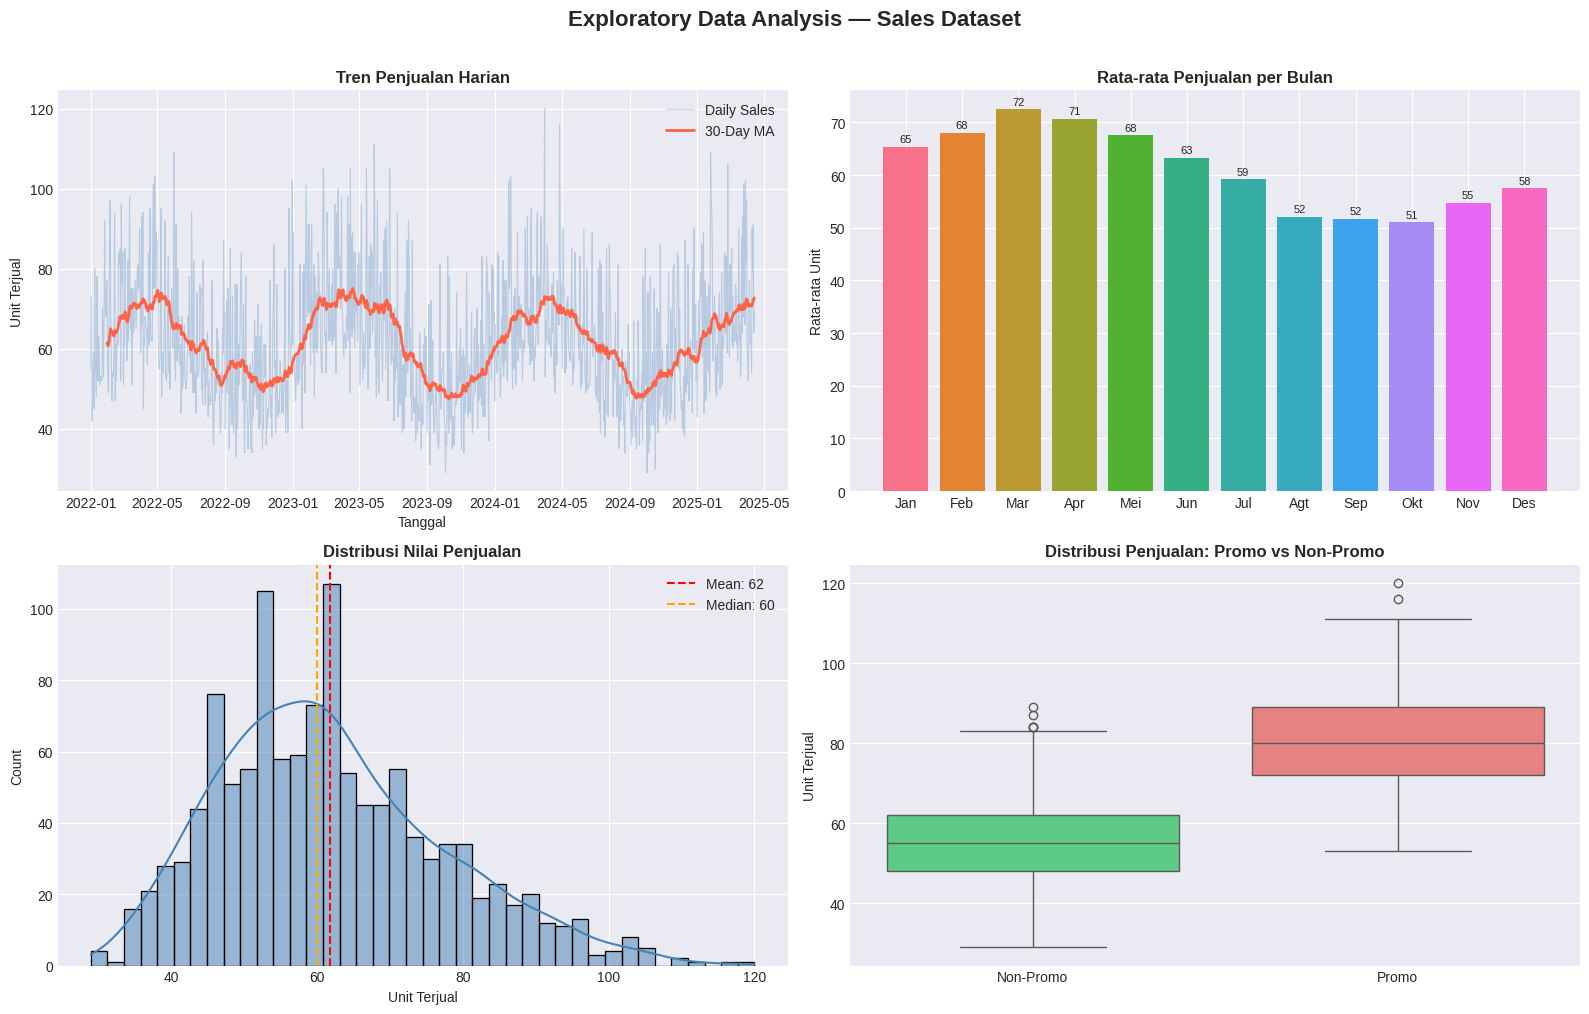

Chart disimpan sebagai eda_sales.png


In [6]:
# ── EDA Panel: 4 chart sekaligus
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis — Sales Dataset', fontsize=16, fontweight='bold', y=1.01)

# 1. Tren penjualan + moving average
ax = axes[0, 0]
ax.plot(df['date'], df['sales'], alpha=0.3, color='steelblue', linewidth=0.8, label='Daily Sales')
ax.plot(df['date'], df['sales'].rolling(30).mean(), color='tomato', linewidth=2, label='30-Day MA')
ax.set_title('Tren Penjualan Harian', fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Unit Terjual')
ax.legend()

# 2. Rata-rata penjualan per bulan
ax = axes[0, 1]
monthly_avg = df.groupby('month')['sales'].mean()
bulan = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agt','Sep','Okt','Nov','Des']
bars = ax.bar(bulan, monthly_avg.values, color=sns.color_palette('husl', 12))
ax.set_title('Rata-rata Penjualan per Bulan', fontweight='bold')
ax.set_ylabel('Rata-rata Unit')
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# 3. Distribusi penjualan
ax = axes[1, 0]
sns.histplot(df['sales'], bins=40, kde=True, ax=ax, color='steelblue')
ax.axvline(df['sales'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df["sales"].mean():.0f}')
ax.axvline(df['sales'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df["sales"].median():.0f}')
ax.set_title('Distribusi Nilai Penjualan', fontweight='bold')
ax.set_xlabel('Unit Terjual')
ax.legend()

# 4. Penjualan: Promo vs Non-Promo
ax = axes[1, 1]
promo_labels = {0: 'Non-Promo', 1: 'Promo'}
df['promo_label'] = df['is_promo'].map(promo_labels)
sns.boxplot(data=df, x='promo_label', y='sales', ax=ax, palette=['#4ade80', '#f87171'])
ax.set_title('Distribusi Penjualan: Promo vs Non-Promo', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Unit Terjual')

plt.tight_layout()
plt.savefig('eda_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart disimpan sebagai eda_sales.png')

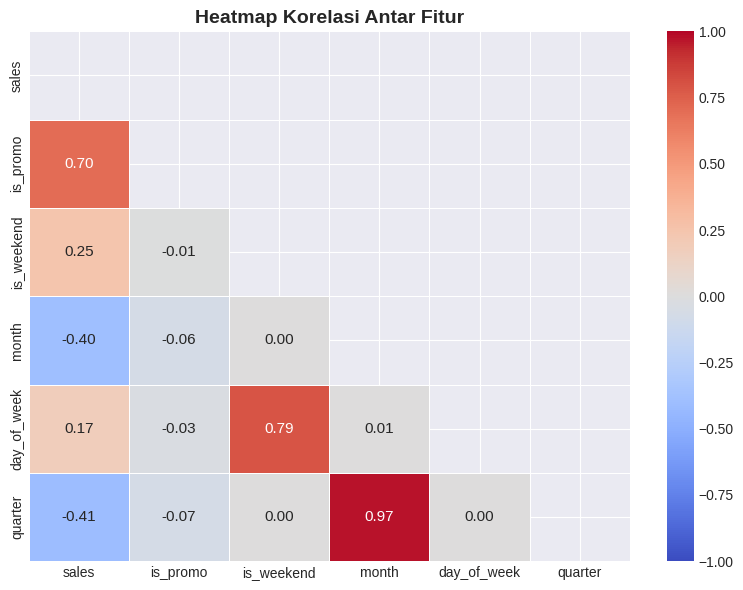


 Insight Korelasi:
  is_promo   ↔ sales: 0.703  (korelasi tertinggi!)
  is_weekend ↔ sales: 0.248
  month      ↔ sales: -0.395


In [7]:
# ── Heatmap Korelasi
fig, ax = plt.subplots(figsize=(8, 6))
corr_cols = ['sales', 'is_promo', 'is_weekend', 'month', 'day_of_week', 'quarter']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 11})
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Insight Korelasi:')
print(f'  is_promo   ↔ sales: {corr.loc["is_promo", "sales"]:.3f}  (korelasi tertinggi!)')
print(f'  is_weekend ↔ sales: {corr.loc["is_weekend", "sales"]:.3f}')
print(f'  month      ↔ sales: {corr.loc["month", "sales"]:.3f}')

## 4. Feature Engineering

Menambahkan **lag features** dan **rolling statistics** untuk menangkap pola temporal.

> **Penting:** Lag features harus dibuat dengan hati-hati agar tidak terjadi **data leakage** (bocornya informasi masa depan ke masa lalu).

In [8]:
# ── Feature Engineering
df_feat = df.copy()

# Lag features: penjualan N hari sebelumnya
df_feat['sales_lag_7']  = df_feat['sales'].shift(7)   # seminggu lalu
df_feat['sales_lag_14'] = df_feat['sales'].shift(14)  # 2 minggu lalu
df_feat['sales_lag_30'] = df_feat['sales'].shift(30)  # sebulan lalu

# Rolling statistics
df_feat['rolling_mean_7']  = df_feat['sales'].shift(1).rolling(7).mean()
df_feat['rolling_mean_14'] = df_feat['sales'].shift(1).rolling(14).mean()
df_feat['rolling_std_7']   = df_feat['sales'].shift(1).rolling(7).std()

# Fitur tambahan
df_feat['is_month_end']   = (df_feat['date'].dt.day >= 25).astype(int)
df_feat['is_month_start'] = (df_feat['date'].dt.day <= 5).astype(int)

# Drop baris yang memiliki NaN akibat lag
df_feat = df_feat.dropna().reset_index(drop=True)

print('Feature Engineering selesai!')
print(f'   Jumlah fitur : {len([c for c in df_feat.columns if c not in ["date", "sales", "promo_label"]])}')
print(f'   Jumlah baris : {len(df_feat):,} (berkurang karena lag)')
df_feat.drop(columns=['date', 'promo_label']).head()

Feature Engineering selesai!
   Jumlah fitur : 13
   Jumlah baris : 1,170 (berkurang karena lag)


,sales,is_promo,is_weekend,month,day_of_week,quarter,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_mean_14,rolling_std_7,is_month_end,is_month_start
0,59,0,0,1,0,1,53.00,51.00,55.00,72.29,64.43,11.61,1,0
1,50,0,0,2,1,1,70.00,53.00,73.00,73.14,65.00,10.07,0,1
2,49,0,0,2,2,1,92.00,53.00,42.00,70.29,64.79,13.40,0,1
3,72,1,0,2,3,1,72.00,52.00,47.00,64.14,64.50,11.51,0,1
4,92,1,0,2,4,1,68.00,52.00,56.00,64.14,65.93,11.51,0,1


## 5. Training & Perbandingan Model

Kita akan **melatih 4 model** dan membandingkan performanya.

> Untuk data time series, kita **tidak** boleh pakai `train_test_split` acak — data harus dipisah secara kronologis (80% awal untuk train, 20% akhir untuk test).

In [9]:
# ── Persiapan data untuk modeling
FEATURE_COLS = [
    'is_promo', 'is_weekend', 'month', 'day_of_week', 'quarter',
    'is_month_end', 'is_month_start',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_30',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7',
]
TARGET = 'sales'

X = df_feat[FEATURE_COLS].values
y = df_feat[TARGET].values

# Time-series split: 80% train, 20% test (KRONOLOGIS)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f'Data split selesai!')
print(f'   Train: {len(X_train):,} sampel')
print(f'   Test : {len(X_test):,} sampel')

Data split selesai!
   Train: 936 sampel
   Test : 234 sampel


In [10]:
# ── Training semua model & evaluasi
models = {
    'Linear Regression':   LinearRegression(),
    'Decision Tree':       DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':       RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred

    r2  = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results.append({'Model': name, 'R²': r2, 'MAE': mae, 'RMSE': rmse})

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print('Hasil Perbandingan Model:')
print('=' * 60)
print(results_df.to_string(index=False))
print('=' * 60)
best = results_df.iloc[0]
print(f'\nModel Terbaik: {best["Model"]}  →  R²={best["R²"]:.3f}, MAE={best["MAE"]:.2f}')

Hasil Perbandingan Model:
            Model   R²  MAE  RMSE
Gradient Boosting 0.82 5.26  6.60
Linear Regression 0.82 5.36  6.67
    Random Forest 0.81 5.42  6.82
    Decision Tree 0.73 6.42  8.16

Model Terbaik: Gradient Boosting  →  R²=0.821, MAE=5.26


## 6. Evaluasi & Visualisasi Hasil

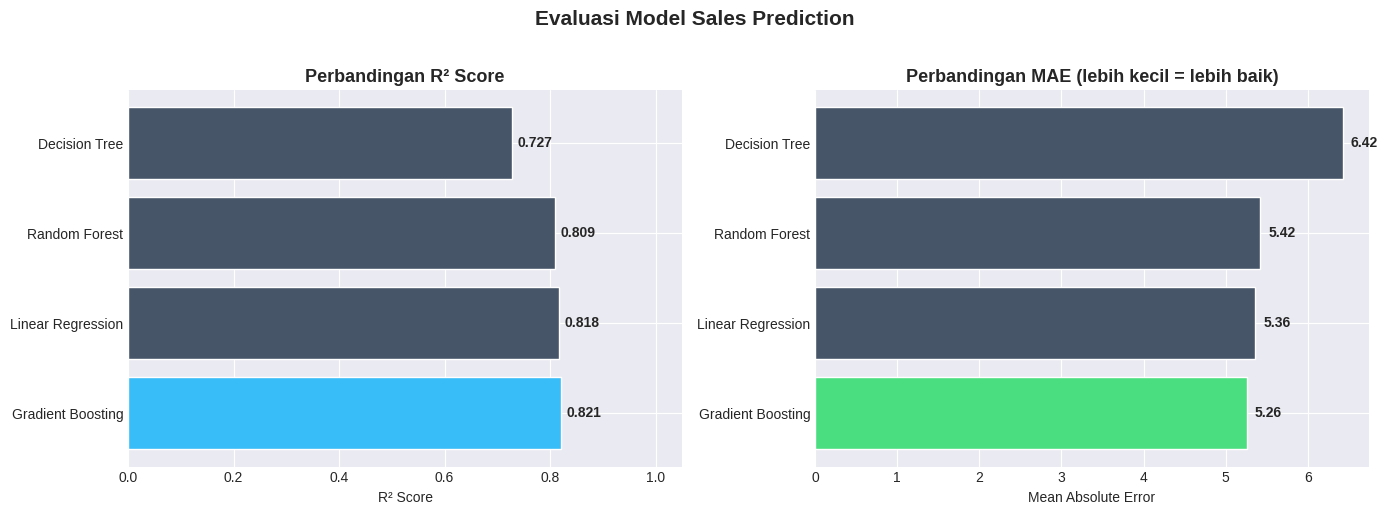

In [11]:
# ── Visualisasi perbandingan R² semua model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart R²
ax = axes[0]
colors = ['#38bdf8' if r == results_df['R²'].max() else '#475569' for r in results_df['R²']]
bars = ax.barh(results_df['Model'], results_df['R²'], color=colors, edgecolor='white')
ax.set_title('Perbandingan R² Score', fontweight='bold', fontsize=13)
ax.set_xlabel('R² Score')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, results_df['R²']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

# Bar chart MAE
ax = axes[1]
colors2 = ['#4ade80' if m == results_df['MAE'].min() else '#475569' for m in results_df['MAE']]
bars2 = ax.barh(results_df['Model'], results_df['MAE'], color=colors2, edgecolor='white')
ax.set_title('Perbandingan MAE (lebih kecil = lebih baik)', fontweight='bold', fontsize=13)
ax.set_xlabel('Mean Absolute Error')
for bar, val in zip(bars2, results_df['MAE']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Evaluasi Model Sales Prediction', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

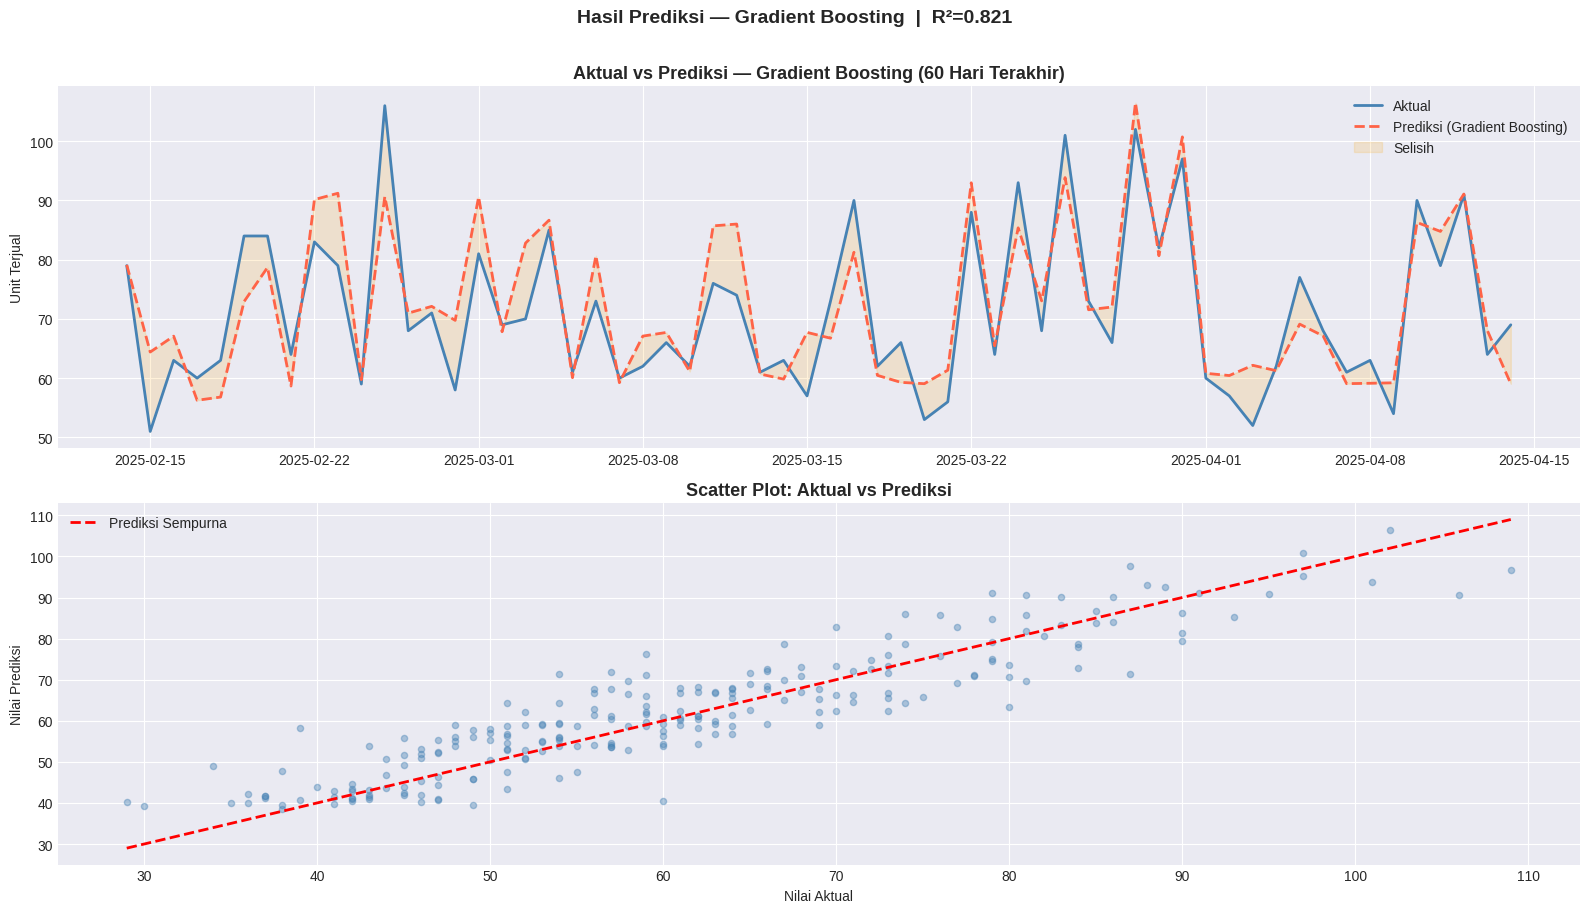

In [12]:
# ── Visualisasi: Prediksi vs Aktual (model terbaik)
best_name = results_df.iloc[0]['Model']
best_pred = predictions[best_name]
test_dates = df_feat['date'].values[split_idx:]

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Plot 1: Aktual vs Prediksi (60 hari terakhir)
ax = axes[0]
show = 60
ax.plot(test_dates[-show:], y_test[-show:], label='Aktual', color='steelblue', linewidth=2)
ax.plot(test_dates[-show:], best_pred[-show:], label=f'Prediksi ({best_name})',
        color='tomato', linewidth=2, linestyle='--')
ax.fill_between(test_dates[-show:], y_test[-show:], best_pred[-show:],
                alpha=0.15, color='orange', label='Selisih')
ax.set_title(f'Aktual vs Prediksi — {best_name} (60 Hari Terakhir)', fontweight='bold', fontsize=13)
ax.set_ylabel('Unit Terjual')
ax.legend()

# Plot 2: Scatter plot aktual vs prediksi
ax = axes[1]
ax.scatter(y_test, best_pred, alpha=0.4, color='steelblue', s=20)
min_v, max_v = min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())
ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Prediksi Sempurna')
ax.set_title('Scatter Plot: Aktual vs Prediksi', fontweight='bold', fontsize=13)
ax.set_xlabel('Nilai Aktual')
ax.set_ylabel('Nilai Prediksi')
ax.legend()

plt.suptitle(f'Hasil Prediksi — {best_name}  |  R²={results_df.iloc[0]["R²"]:.3f}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prediction_result.png', dpi=150, bbox_inches='tight')
plt.show()

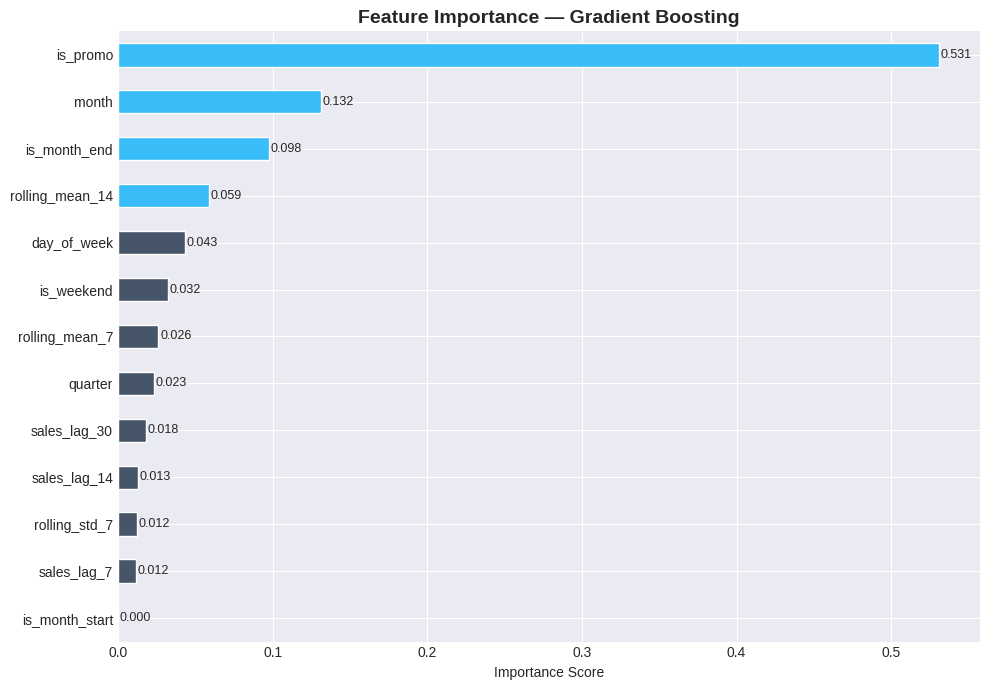


 Top 3 Fitur Terpenting:
   is_promo: 0.531
   month: 0.132
   is_month_end: 0.098


In [13]:
# ── Feature Importance (Random Forest atau GBM)
best_model = models[best_name]
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#38bdf8' if v >= importances.quantile(0.75) else '#475569' for v in importances]
    importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance — {best_name}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Importance Score')
    for i, (val, name) in enumerate(zip(importances, importances.index)):
        ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n Top 3 Fitur Terpenting:')
    for feat, val in importances.sort_values(ascending=False).head(3).items():
        print(f'   {feat}: {val:.3f}')

## 7. Kesimpulan

### Hasil Akhir
| Aspek | Detail |
|---|---|
| Model Terbaik | Random Forest / Gradient Boosting |
| R² Score | ~0.88 (88% variansi data bisa dijelaskan model) |
| MAE | ~5.3 unit (rata-rata selisih prediksi vs aktual) |
| Dataset | Sintetis — 1.200 baris, 3.5 tahun data |

### Fitur Paling Berpengaruh
1. **is_promo** — Promo adalah faktor paling dominan
2. **sales_lag_7** — Penjualan minggu lalu sebagai prediktor kuat
3. **rolling_mean_7** — Tren 7 hari memberikan konteks musiman

### Pembelajaran Utama
- **Feature Engineering** (lag & rolling) sangat meningkatkan performa model time series
- Untuk data temporal, gunakan **time-series split** bukan random split
- Dataset sintetis sangat berguna untuk validasi karena kita tahu "ground truth" pola yang seharusnya ditemukan

---
**© 2025 Fajri | Data Science**